## Setup
We import libraries, load the data, sort by time, and set the seed for reproducibility.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_theme(style='whitegrid')

# Reproducibility
np.random.seed(42)

# Load and sort immediately by time key
df = pd.read_csv('final.csv')
df['Year_Week'] = df['Year_Week'].astype(str)
df = df.sort_values('Year_Week', ascending=True).reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f"Time range (full): {df['Year_Week'].min()} -> {df['Year_Week'].max()}")

Dataset shape: (61152, 16)
Time range (full): 2013-w1 -> 2019-w9


## Step 1 — Data preparation
We prepare the data for modeling. Instead of splitting randomly, we split by time — the model learns from the past and is tested on the future. This is the correct way to handle time series data.

In [2]:
# Prepare modeling dataframe
df_model = df.copy()
df_model = df_model.dropna(subset=['retail_price']).copy()
df_model['mean_farmer_price'] = df_model['mean_farmer_price'].fillna(df_model['mean_farmer_price'].median())

feature_cols = [
    'week',
    'no_of_holidays',
    'lanka_auto_diesel_price',
    'mean_apparent_temperature',
    'rain_sum',
    'usd_exchange_rate',
    'mean_farmer_price',
    'vegetable_zone',
    'seasonality',
    'vegetable_type',
    'retail_market'
]
target_col = 'retail_price'

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

# Keep original market labels for later per-market evaluation
market_labels = df_model['retail_market'].copy()

# Fresh label encoding for this model setup
categorical_cols = ['vegetable_zone', 'seasonality', 'vegetable_type', 'retail_market', 'week']
encoders_unified = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders_unified[col] = le

# Time-based split with iloc (no shuffle)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_train, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()

train_time_start = df_model.iloc[:split_idx]['Year_Week'].min()
train_time_end = df_model.iloc[:split_idx]['Year_Week'].max()
test_time_start = df_model.iloc[split_idx:]['Year_Week'].min()
test_time_end = df_model.iloc[split_idx:]['Year_Week'].max()

print(f'Train rows: {len(X_train):,} | Test rows: {len(X_test):,}')
print(f'Train Year_Week range: {train_time_start} -> {train_time_end}')
print(f'Test Year_Week range:  {test_time_start} -> {test_time_end}')

Train rows: 48,921 | Test rows: 12,231
Train Year_Week range: 2013-w1 -> 2018-w38
Test Year_Week range:  2018-w38 -> 2019-w9


## Step 2 — Model 1: Unified model on full dataset
We train one XGBoost model on all 14 markets together. This is the baseline — one model that tries to learn price patterns for every market at once.

In [3]:
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

xgb_params = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

model_unified = xgb.XGBRegressor(**xgb_params)
model_unified.fit(X_train, y_train)
y_pred_unified = model_unified.predict(X_test)

mae_all, rmse_all, r2_all = calc_metrics(y_test, y_pred_unified)

overall_metrics_table = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Value': [mae_all, rmse_all, r2_all],
    'Meaning': ['Average prediction error in Rs.', 'Root Mean Squared Error in Rs.', 'Variance explained (1.0 = perfect)']
})
overall_metrics_table['Value'] = overall_metrics_table['Value'].round(4)

display(overall_metrics_table)

,Metric,Value,Meaning
0,MAE,23.4217,Average prediction error in Rs.
1,RMSE,35.8611,Root Mean Squared Error in Rs.
2,R²,0.8611,Variance explained (1.0 = perfect)


## Step 3 — Per-market accuracy from the unified model
A good overall score can hide a bad score for one specific market. Here we break the unified model's accuracy down by each market to see if any market is being predicted poorly.

,Market,MAE,RMSE,R²,n_test_rows
0,Thambuththegama,25.4289,39.2578,0.7937,874
1,Kaluthara,29.9117,46.1554,0.8070,872
2,Puttalam,26.4881,39.2767,0.8218,874
3,Kurunegala,26.4201,35.5398,0.8311,874
4,Badulla,25.0508,39.9220,0.8333,873
5,Nuwaraeliya,21.7895,34.4309,0.8442,874
6,Mathara,25.0870,38.9009,0.8524,873
7,Meegoda,21.2241,31.2664,0.8696,874
8,Anuradhapura,23.6812,36.7112,0.8769,874
9,Hambanthota,19.9854,31.6961,0.8850,873


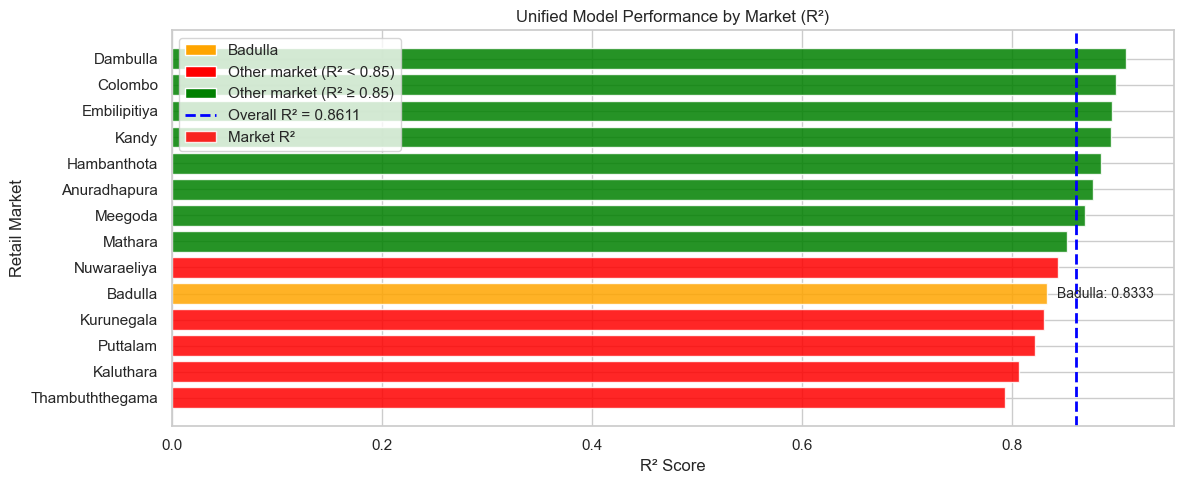

In [4]:
# Attach original string labels to test rows by index alignment
test_eval_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred_unified
}, index=y_test.index)
test_eval_df['retail_market'] = market_labels.loc[test_eval_df.index]

all_markets = sorted(df_model['retail_market'].dropna().astype(str).unique())
market_rows = []

for market in all_markets:
    subset = test_eval_df[test_eval_df['retail_market'] == market]
    if len(subset) == 0:
        market_rows.append({'Market': market, 'MAE': np.nan, 'RMSE': np.nan, 'R²': np.nan, 'n_test_rows': 0})
        continue

    mae_m, rmse_m, r2_m = calc_metrics(subset['y_true'], subset['y_pred'])
    market_rows.append({
        'Market': market,
        'MAE': round(mae_m, 4),
        'RMSE': round(rmse_m, 4),
        'R²': round(r2_m, 4),
        'n_test_rows': len(subset)
    })

market_metrics_df = pd.DataFrame(market_rows).sort_values('R²', ascending=True, na_position='last').reset_index(drop=True)
display(market_metrics_df)

# Horizontal bar chart of R² per market
plot_df = market_metrics_df.dropna(subset=['R²']).copy()
colors = []
for _, row in plot_df.iterrows():
    if row['Market'] == 'Badulla':
        colors.append('orange')
    elif row['R²'] < 0.85:
        colors.append('red')
    else:
        colors.append('green')

fig, ax = plt.subplots(figsize=(12, max(5, len(plot_df) * 0.35)))
bars = ax.barh(plot_df['Market'], plot_df['R²'], color=colors, alpha=0.85, label='Market R²')
ax.axvline(r2_all, color='blue', linestyle='--', linewidth=2, label=f'Overall R² = {r2_all:.4f}')

# Annotate Badulla bar
for bar, market, val in zip(bars, plot_df['Market'], plot_df['R²']):
    if market == 'Badulla':
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'Badulla: {val:.4f}', va='center', fontsize=10)

from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor='orange', label='Badulla'),
    Patch(facecolor='red', label='Other market (R² < 0.85)'),
    Patch(facecolor='green', label='Other market (R² ≥ 0.85)')
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=legend_items + handles, loc='best')

ax.set_title('Unified Model Performance by Market (R²)')
ax.set_xlabel('R² Score')
ax.set_ylabel('Retail Market')
plt.tight_layout()
plt.show()

## Step 4 — Non-Badulla accuracy from the unified model
Here we check how the unified model performs when Badulla is excluded from the evaluation. This shows whether Badulla is dragging down the overall score.

In [5]:
non_badulla_test = test_eval_df[test_eval_df['retail_market'] != 'Badulla'].copy()

mae_nonbad_u, rmse_nonbad_u, r2_nonbad_u = calc_metrics(non_badulla_test['y_true'], non_badulla_test['y_pred'])

comparison_all_vs_nonbadulla = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'All markets': [mae_all, rmse_all, r2_all],
    'Without Badulla': [mae_nonbad_u, rmse_nonbad_u, r2_nonbad_u]
})
comparison_all_vs_nonbadulla[['All markets', 'Without Badulla']] = comparison_all_vs_nonbadulla[['All markets', 'Without Badulla']].round(4)

display(comparison_all_vs_nonbadulla)

,Metric,All markets,Without Badulla
0,MAE,23.4217,23.2964
1,RMSE,35.8611,35.5297
2,R²,0.8611,0.8633


## Step 5 — Model 2: Badulla-only model
Now we train a completely separate XGBoost model using only Badulla data. The idea is that a specialist model that only knows Badulla might learn its unique patterns better than a general model.

In [6]:
# Unified model performance on Badulla rows only (from existing unified predictions)
badulla_unified_eval = test_eval_df[test_eval_df['retail_market'] == 'Badulla'].copy()
if len(badulla_unified_eval) == 0:
    raise ValueError('No Badulla rows found in test set for unified model evaluation.')

mae_bad_u, rmse_bad_u, r2_bad_u = calc_metrics(badulla_unified_eval['y_true'], badulla_unified_eval['y_pred'])

# Build Badulla-only dataset from original sorted dataframe (before encoding)
df_bad = df[df['retail_market'] == 'Badulla'].copy()
df_bad = df_bad.dropna(subset=['retail_price']).copy()
df_bad['mean_farmer_price'] = df_bad['mean_farmer_price'].fillna(df_bad['mean_farmer_price'].median())

X_bad = df_bad[feature_cols].copy()
y_bad = df_bad[target_col].copy()

# Fresh independent encoding for Badulla-only model
encoders_badulla = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_bad[col] = le.fit_transform(X_bad[col].astype(str))
    encoders_badulla[col] = le

split_bad = int(len(X_bad) * 0.8)
X_bad_train, X_bad_test = X_bad.iloc[:split_bad].copy(), X_bad.iloc[split_bad:].copy()
y_bad_train, y_bad_test = y_bad.iloc[:split_bad].copy(), y_bad.iloc[split_bad:].copy()

print(f"Badulla train Year_Week range: {df_bad.iloc[:split_bad]['Year_Week'].min()} -> {df_bad.iloc[:split_bad]['Year_Week'].max()}")
print(f"Badulla test Year_Week range:  {df_bad.iloc[split_bad:]['Year_Week'].min()} -> {df_bad.iloc[split_bad:]['Year_Week'].max()}")

model_badulla = xgb.XGBRegressor(**xgb_params)
model_badulla.fit(X_bad_train, y_bad_train)
y_pred_bad = model_badulla.predict(X_bad_test)

mae_bad, rmse_bad, r2_bad = calc_metrics(y_bad_test, y_pred_bad)

badulla_compare_table = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Unified model (Badulla rows)': [mae_bad_u, rmse_bad_u, r2_bad_u],
    'Badulla-only model': [mae_bad, rmse_bad, r2_bad]
})
badulla_compare_table[['Unified model (Badulla rows)', 'Badulla-only model']] = badulla_compare_table[['Unified model (Badulla rows)', 'Badulla-only model']].round(4)

display(badulla_compare_table)

Badulla train Year_Week range: 2013-w1 -> 2018-w38
Badulla test Year_Week range:  2018-w38 -> 2019-w9


,Metric,Unified model (Badulla rows),Badulla-only model
0,MAE,25.0508,24.1943
1,RMSE,39.9220,41.4397
2,R²,0.8333,0.8203


## Step 6 — Model 3: Non-Badulla model
We train a third XGBoost model on the 13 non-Badulla markets only. Without Badulla's different behaviour in the training data, this model may learn cleaner patterns for the other markets.

In [7]:
# Build non-Badulla dataset from original sorted dataframe
df_nonbad = df[df['retail_market'] != 'Badulla'].copy()
df_nonbad = df_nonbad.dropna(subset=['retail_price']).copy()
df_nonbad['mean_farmer_price'] = df_nonbad['mean_farmer_price'].fillna(df_nonbad['mean_farmer_price'].median())

X_nonbad = df_nonbad[feature_cols].copy()
y_nonbad = df_nonbad[target_col].copy()

# Fresh independent encoding for non-Badulla model
encoders_nonbadulla = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_nonbad[col] = le.fit_transform(X_nonbad[col].astype(str))
    encoders_nonbadulla[col] = le

split_nonbad = int(len(X_nonbad) * 0.8)
X_nonbad_train, X_nonbad_test = X_nonbad.iloc[:split_nonbad].copy(), X_nonbad.iloc[split_nonbad:].copy()
y_nonbad_train, y_nonbad_test = y_nonbad.iloc[:split_nonbad].copy(), y_nonbad.iloc[split_nonbad:].copy()

print(f"Non-Badulla train Year_Week range: {df_nonbad.iloc[:split_nonbad]['Year_Week'].min()} -> {df_nonbad.iloc[:split_nonbad]['Year_Week'].max()}")
print(f"Non-Badulla test Year_Week range:  {df_nonbad.iloc[split_nonbad:]['Year_Week'].min()} -> {df_nonbad.iloc[split_nonbad:]['Year_Week'].max()}")

model_nonbadulla = xgb.XGBRegressor(**xgb_params)
model_nonbadulla.fit(X_nonbad_train, y_nonbad_train)
y_pred_nonbad = model_nonbadulla.predict(X_nonbad_test)

mae_nonbad, rmse_nonbad, r2_nonbad = calc_metrics(y_nonbad_test, y_pred_nonbad)

nonbadulla_compare_table = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Unified model (non-Badulla rows)': [mae_nonbad_u, rmse_nonbad_u, r2_nonbad_u],
    'Non-Badulla model': [mae_nonbad, rmse_nonbad, r2_nonbad]
})
nonbadulla_compare_table[['Unified model (non-Badulla rows)', 'Non-Badulla model']] = nonbadulla_compare_table[['Unified model (non-Badulla rows)', 'Non-Badulla model']].round(4)

display(nonbadulla_compare_table)

Non-Badulla train Year_Week range: 2013-w1 -> 2018-w38
Non-Badulla test Year_Week range:  2018-w38 -> 2019-w9


,Metric,Unified model (non-Badulla rows),Non-Badulla model
0,MAE,23.2964,23.7467
1,RMSE,35.5297,36.0567
2,R²,0.8633,0.8592


## Step 7 — Final summary comparison
We bring all results together in one place to decide which modeling strategy works best.

,Model,MAE,RMSE,R²
0,Unified model — all 14 markets,23.4217,35.8611,0.8611
1,Unified model — Badulla rows only,25.0508,39.9220,0.8333
2,Badulla-only specialist model,24.1943,41.4397,0.8203
3,Non-Badulla specialist model,23.7467,36.0567,0.8592


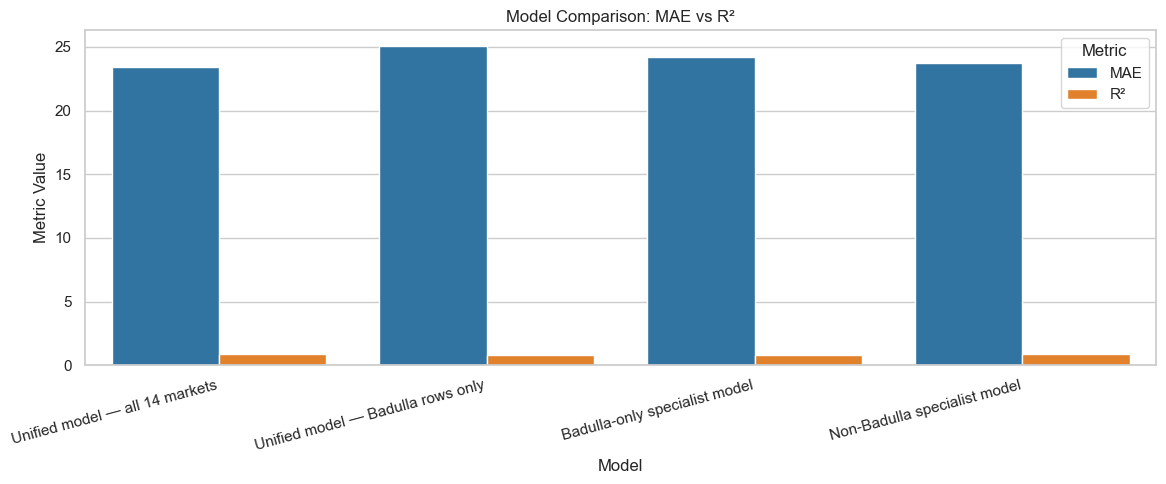

In [8]:
final_summary = pd.DataFrame([
    {'Model': 'Unified model — all 14 markets', 'MAE': mae_all, 'RMSE': rmse_all, 'R²': r2_all},
    {'Model': 'Unified model — Badulla rows only', 'MAE': mae_bad_u, 'RMSE': rmse_bad_u, 'R²': r2_bad_u},
    {'Model': 'Badulla-only specialist model', 'MAE': mae_bad, 'RMSE': rmse_bad, 'R²': r2_bad},
    {'Model': 'Non-Badulla specialist model', 'MAE': mae_nonbad, 'RMSE': rmse_nonbad, 'R²': r2_nonbad}
])

display(final_summary.round(4))

# Grouped bar chart comparing MAE and R²
plot_compare = final_summary[['Model', 'MAE', 'R²']].melt(id_vars='Model', var_name='Metric', value_name='Value')

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_compare, x='Model', y='Value', hue='Metric', palette={'MAE': '#1f77b4', 'R²': '#ff7f0e'})
plt.title('Model Comparison: MAE vs R²')
plt.xlabel('Model')
plt.ylabel('Metric Value')
plt.xticks(rotation=15, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

### Interpretation (read after running all cells)
- If the **Badulla-only specialist model** has lower MAE/RMSE and higher R² than **Unified model — Badulla rows only**, then splitting Badulla into its own model improved Badulla accuracy.
- If **Without Badulla** (Step 4) is clearly better than **All markets**, then the unified model is likely being penalised by Badulla's different behaviour.
- If the **Non-Badulla specialist model** beats **Unified model (non-Badulla rows)**, then training non-Badulla separately also helps the other markets.
- If specialist models improve both segments, a practical strategy is a **two-model system**: one for Badulla and one for all other markets.
- If gains are small, keep the unified model for simplicity; if gains are large and consistent, deploy split specialist models.